---

## **Prerequisites / Setup**

$\Rightarrow$ Special setup instructions, imports and configurations go here.


# **Project work: A mini segmentation challenge**
## Segmentation of diseased leaves
<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Student**: $\Rightarrow$ Rebecca Siebeneicher, Maria Morales
**Email**: $\Rightarrow$ siebere2@students.zhaw.ch, moralma1@students.zhaw.ch
**University**: $\Rightarrow$  ZHAW
**Semester**: $\Rightarrow$  FS 2026 
**Date**: $\Rightarrow$  31.05.2026


<br>

## **Abstract**

*$\Rightarrow$ Segmentation of dark spots on diseased tree leaves. Comparison of the results between manual and automatic segmentation process.*



<br><br>

----

## **Table of contents**
<!-- Unfortunately, the following does not always work correctly -->
* [1. Dataset](#sec_dataset)  
* [2. Preprocessing](#sec_preprocessing)  
* [3. Manual segmentation](#sec_manual_segmentation)  
* [4. Automated segmentation](#sec_automated_segmentation)  
* [5. Evaluation](#sec_evaluation)  
* [6. Discussion](#sec_discussion)  
* [Appendix: Hints](#sec_hints)  


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2 as cv
import PIL

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

# Enable this line if you want to use the interactive widgets
# It requires the ipympl package to be installed.
#%matplotlib widget

import sys
sys.path.insert(0, "../")
import tools

---


<a id='sec_dataset'></a>

## **Dataset**
Apple scab is one of the most common diseases in apples all around the world, caused by a fungus. It results in the highest apple loss caused by a disease. Although infected trees cannot be cured, the disease can be controlled, and its spread to neighboring trees can be effectively prevented. For this reason, considerable effort is invested in prevention. However, early detection remains essential once the disease has occurred. Typical symptoms include dark lesions on both leaves and fruit (Vaillancourt & Hartman, 2000).

The aim of this project is therefore to segment the diseased regions on apple leaves affected by apple scab.

The original dataset was provided by Pandian and Gopal (2019) and consists of 1000 images of apple leaves showing symptoms of apple scab. According to the usage license, the dataset can be freely copied, modified, distributed, and used without requiring permission. For this project, the dataset was filtered to include only images captured under shadow conditions, showing flat leaves, and ensuring that each image represents a different leaf. After this selection process, 12 images remained.
The images were acquired using standard RGB digital photography. The structures of interest are the leaf itself and the dark spots caused by the apple scab fungus.

In [ ]:
# Import the 12 selected images of leaves with apple scab
folder_path_data = "/Users/rebeccasiebeneicher/Documents/Master/Semester_2/CO4/Projekt/Data_Project_CO4/"

images = [cv.imread(os.path.join(folder_path_data, f))
          for f in sorted(os.listdir(folder_path_data)) if f.endswith(".JPG")]

---

<a id='sec_preprocessing'></a>

## **Preprocessing**
As shown in the code block below, all 12 selected images have identical dimensions and formats. Therefore, no standardization was necessary.
Since the contrast between the background and the leaf is sufficiently strong in all images, no additional preprocessing was needed before creating the manual and automated masks of the leaves. 

Fill in the part for the dark spot masks after we get feedback form Norman. 


### **Instructions:**
* Improve image quality by reducing noise, adjusting contrast, or normalizing intensity.
* Standardize image dimensions and formats for consistent input to analysis pipelines.
* Highlight or isolate relevant structures to support downstream processing.




In [32]:
# Checking the image dimensions and formats of the original images
for img in images:
    print(img.shape, img.dtype)



(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8


---

<a id='sec_manual_segmentation'></a>

## **Manual segmentation**
As described in the chapter Dataset, 12 images of leaves with dark spots coming from a apple scab disease were selected. For each image two masks were manually created using Fiji. The first mask separates the background and the leaf. The second mask separates the dark spots and the leaf. This was done in two different steps, to ensure, that the background will not be counted as a dark spot, since the background and the dark spots are quite similar in colour. 

Fiji was chosen for the manual segmentation in this project because it is a widely used, free, and open-source software for scientific image analysis (Schindelin et al., 2012). Originally developed for applications in cell biology and microscopy, it offers a broad range of plugins that make it well suited for segmenting images with clear structural features and colour contrasts (Arganda-Carreras et al., 2017), as is the case for the dataset used for this project.

#### **Description Segmentation leaf and background:**
As mentioned in the chapter preprocessing, for the segmentation of the leaves and the background no preprocessing was necessary, since the contrast between the green leaf and the dark background was strong enough to directly use colour thresholding. The exact thresholding parameters used for each image are provided in the appendix. 
Due to the similarity in colour between the dark spots and the background, the initial thresholding often resulted in small holes within the leaf region. These were corrected using the “Fill Holes” function. In some cases, additional manual adjustments were necessary, particularly when dark spots were located at the leaf edges, when shadows affected the leaf boundary, or when the leaf had physical damage such as tears.

The creation of each mask required approximately 2–3 minutes. The final masks separating leaf and background are provided at the end of this chapter.

#### **Description Segmentation leaf and dark spots:**
As described in the chapter preprocessing in more detail, different settings to enhance the contrast between the dark spots and the leaf were tested. After that colour thresholding or thresholding was used. None of the resulting masks was usable, since big parts of the leaves and only parts of the dark spots were selected. Consequently, the segmentation of the dark spots was performed manually using the Region of Interest (ROI) Manager. Each dark spot was individually outlined and stored, and a final mask was generated from these regions.

This process presented several challenges. Upon closer inspection, the dark spots were found to consist not only of dark pixels but also of varying shades of green, making it difficult to clearly distinguish between diseased and healthy reagions. This ambiguity also explains why the thresholding methods did not work.

Additionally, this manual approach is not scalable to larger datasets, as it required approximately 2–6 minutes per image, depending on the number and complexity of the dark spots present.

In [ ]:
# Import the 12 manually created masks of the leaves
folder_path_leaves = "/Users/rebeccasiebeneicher/Documents/Master/Semester_2/CO4/Projekt/Masks/leaves"

manual_masks_leaves = [cv.imread(os.path.join(folder_path_leaves, m))
          for m in sorted(os.listdir(folder_path_leaves)) if m.endswith(".png")]


# Imort the 12 manually created masks of the dark spots on the leaves
folder_path_spots = "/Users/rebeccasiebeneicher/Documents/Master/Semester_2/CO4/Projekt/Masks/dark_spots"

manual_masks_dark_spots = [cv.imread(os.path.join(folder_path_spots, m))
          for m in sorted(os.listdir(folder_path_spots)) if m.endswith(".png")]

---

<a id='sec_automated_segmentation'></a>

## **Automated Segmentation**

*$\Rightarrow$ Describe how the images are segmented using Python.*

### **Instructions:**
* Perform the segmentation in Python.
* You may use external libraries or tools (e.g., OpenCV, scikit-image).
* Implement a function `segment(image, ...)` that takes an image as input and returns a segmentation mask for the structure of interest.


Dark S range: 17 - 108
Dark V range: 43 - 125
Healthy S range: 51 - 134
Healthy V range: 82 - 149


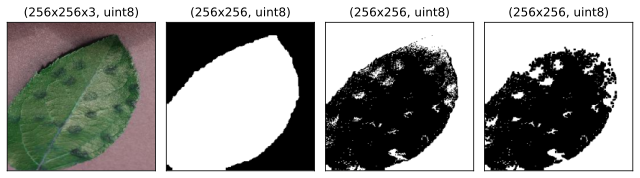

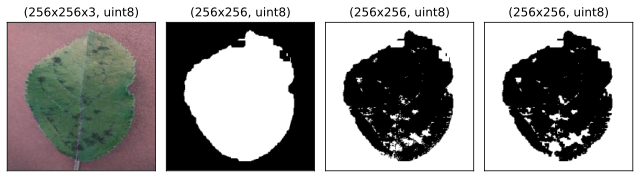

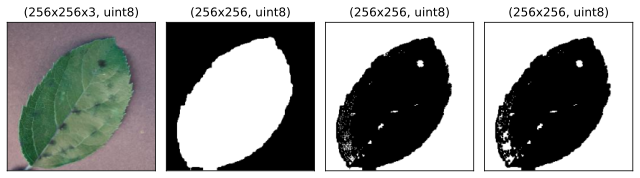

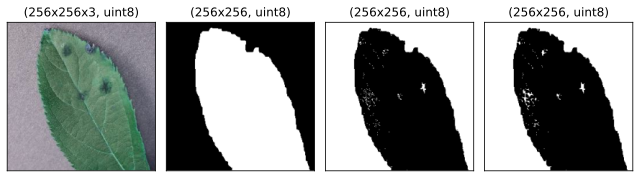

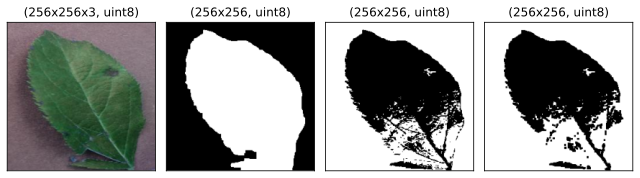

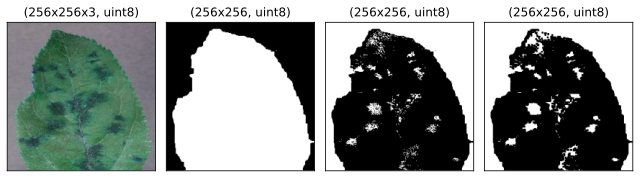

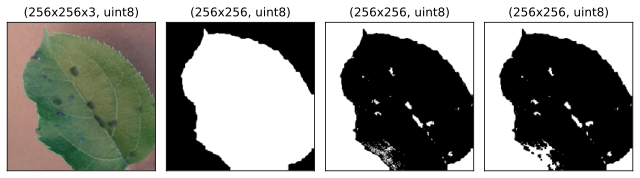

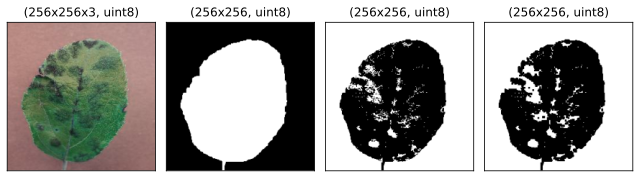

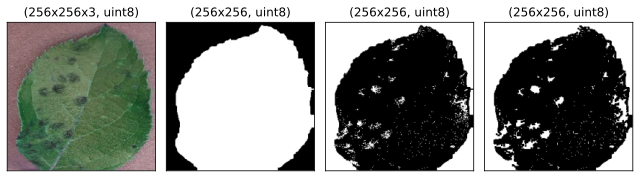

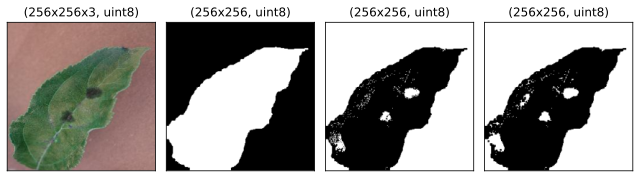

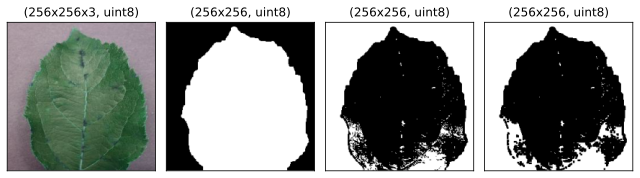

In [32]:
images = [cv.imread(os.path.join("data/leaves", f))
          for f in sorted(os.listdir("data/leaves")) if f.endswith(".JPG")]
dark_spots = [cv.imread(os.path.join("data/dark-spots", f))
          for f in sorted(os.listdir("data/dark-spots")) if f.endswith(".JPG")]
healthy_tissue = [cv.imread(os.path.join("data/healthy-spots", f))
          for f in sorted(os.listdir("data/healthy-spots")) if f.endswith(".JPG")]

def sample_spots (dark, healthy):
    dark_hsv = cv.cvtColor(dark, cv.COLOR_BGR2HSV)
    healthy_hsv = cv.cvtColor(healthy, cv.COLOR_BGR2HSV)
    #Sample points in dark and healthy tissue
    dark_values = [dark_hsv[4,4],dark_hsv[8,4],dark_hsv[8,4],dark_hsv[8,8]]
    healthy_values = [healthy_hsv[10,10],healthy_hsv[20,10],healthy_hsv[10,20],healthy_hsv[20,20]]
    dark_s = [v[1] for v in dark_values]
    dark_v = [v[2] for v in dark_values]
    healthy_s = [v[1] for v in healthy_values]
    healthy_v = [v[2] for v in healthy_values]
    return dark_s, dark_v, healthy_s, healthy_v

dark_svalues = []
dark_vvalues = []
healthy_svalues = []
healthy_vvalues = []

for (dark, healthy) in zip(dark_spots, healthy_tissue):
    dark_s, dark_v, healthy_s, healthy_v = sample_spots(dark, healthy)
    dark_svalues.extend(dark_s)
    dark_vvalues.extend(dark_v)
    healthy_svalues.extend(healthy_s)
    healthy_vvalues.extend(healthy_v)

print(f"Dark S range: {min(dark_svalues)} - {max(dark_svalues)}")
print(f"Dark V range: {min(dark_vvalues)} - {max(dark_vvalues)}")
print(f"Healthy S range: {min(healthy_svalues)} - {max(healthy_svalues)}")
print(f"Healthy V range: {min(healthy_vvalues)} - {max(healthy_vvalues)}")

def segment(img,dsv_min,dsv_max,dvv_min,dvv_max):
    img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Plot the hue histogram
    #plt.hist(img_hsv[:,:,0].flatten(), bins=180, range=[0,180])
    #plt.xlabel("Hue value")
    #plt.ylabel("Pixel count")
    #plt.title("Hue distribution")
    #plt.show()

    # Sample a pixel that is a leaf
    #print("Leaf pixel HSV:", img_hsv[100, 100]) 
    # Sample background
    #print("Background pixel HSV:", img_hsv[0, 0])

    green_lower = np.array([30,  0, 0])
    green_upper = np.array([85, 255, 255])
    leaf_holes_mask = cv.inRange(img_hsv, green_lower, green_upper)
    #tools.display_image(leaf_holes_mask)

    size = (9, 9)
    se = cv.getStructuringElement(cv.MORPH_RECT, size)
    leaf_mask = cv.morphologyEx(leaf_holes_mask, cv.MORPH_CLOSE, se, iterations=1)
    #tools.display_image(leaf_mask)

    leaf = img_rgb.copy()
    leaf[leaf_mask == 0] = [0, 0, 0]
    #tools.display_image(leaf)

    spots_lower = np.array([0,  0, 0])
    spots_upper = np.array([255, 75, 100])
    spots_mask = cv.inRange(leaf, spots_lower, spots_upper)
    size = (3, 3)
    se = cv.getStructuringElement(cv.MORPH_RECT, size)
    spots_mask_closed = cv.morphologyEx(spots_mask, cv.MORPH_CLOSE, se, iterations=1)

    tools.show_image_chain([img,leaf_mask,spots_mask,spots_mask_closed])

for img in images:
    segment(img,min(dark_svalues),min(healthy_svalues),min(dark_vvalues),min(healthy_vvalues))

---

<a id='sec_evaluation'></a>

## **Evaluation**
*$\Rightarrow$ Describe the evaluation of your results.*

### **Instructions:**
* Select an evaluation method to compare two binary segmentation masks and quantify how well they match (e.g., using the Dice score).
* Hint: Implement a function `evaluate(mask1, mask2)` that returns the chosen evaluation score(s).
* Calculate the mean and standard deviation of the scores across the entire dataset.



In [ ]:
# Metric functions dice and iou (the code provided during the lecture was used to implement these functions)
def dice(mask1, mask2):
    """Compute the Dice coefficient. . The input masks should be binary."""
    assert mask1.shape == mask2.shape
    assert mask1.dtype == bool and mask2.dtype == bool
    intersection = mask1 & mask2  
    return 2*np.sum(intersection)/(np.sum(mask1) + np.sum(mask2))   


def iou(mask1, mask2):
    """Compute the Intersection over Union coefficient. The input masks should be binary."""
    assert mask1.shape == mask2.shape
    assert mask1.dtype == bool and mask2.dtype == bool
    intersection = mask1 & mask2
    union = mask1 | mask2
    return np.sum(intersection)/np.sum(union)


# Evaluation function -> here the manually created and the automated masks are compared indivudually using the dice and iou functions 
def evaluate(auto_mask, manual_mask):
    """ If necessary, converts the masks to grayscale and compares the automated mask with the manual mask and returns the Dice and IoU scores."""
    if auto_mask.ndim == 3:
        auto_mask = cv.cvtColor(auto_mask, cv.COLOR_BGR2GRAY)
    if manual_mask.ndim == 3:
        manual_mask = cv.cvtColor(manual_mask, cv.COLOR_BGR2GRAY)

    return {"Dice" : dice(auto_mask > 0, manual_mask > 0), 
            "IoU" : iou(auto_mask > 0, manual_mask > 0)}

# Calculate the evaluation scores and storing them in a list
scores_leaves = [evaluate(auto, manual)
                 for auto, manual in zip(auto_masks_leaves, manual_masks_leaves)]

scores_spots = [evaluate(auto, manual)
                for auto, manual in zip(auto_masks_dark_spots, manual_masks_dark_spots)]

#Calculate the mean and the standard deviation across all leaf masks and all dark spots masks
df_leaves = pd.DataFrame(scores_leaves)
df_spots = pd.DataFrame(scores_spots)

print("=== Leaf masks: mean ± std ===")
display(df_leaves.agg(["mean", "std"]).round(4))

print("\n=== Dark spot masks: mean ± std ===")
display(df_spots.agg(["mean", "std"]).round(4))

---

<a id='sec_discussion'></a>

## **Discussion**

*$\Rightarrow$ Briefly discuss your results and share your key observations and your experiences and leaernings.*



---

<a id='sec_references'></a>

## **References**
Arganda-Carreras, I., Kaynig, V., Rueden, C., Eliceiri, K. W., Schindelin, J., Cardona, A., & Sebastian Seung, H. (2017). Trainable Weka Segmentation: a machine learning tool for microscopy pixel classification. Bioinformatics, 33(15), 2424–2426. https://doi.org/10.1093/bioinformatics/btx180

Schindelin, J., Arganda-Carreras, I., Frise, E., Kaynig, V., Longair, M., Pietzsch, T., Preibisch, S., Rueden, C., Saalfeld, S., Schmid, B., Tinevez, J.-Y., White, D. J., Hartenstein, V., Eliceiri, K., Tomancak, P., & Cardona, A. (2012). Fiji: an open-source platform for biological-image analysis. Nature Methods, 9(7), 676–682. https://doi.org/10.1038/nmeth.2019

Vaillancourt, L. J., & Hartman, J. R. (2000). Apple scab. The Plant Health Instructor. American Phytopathological Society. https://www.apsnet.org/edcenter/pdlessons/Pages/AppleScab.aspx

The code provided during the CO4 lecture was used in parts of this project 

*$\Rightarrow$ List all relevant references (as URLs).*

## **Decleration on the usage of AI**

*Also, clearly state whether you used generative AI tools (e.g., ChatGPT, GitHub Copilot) and describe how they were used.*



<br><br><br><br><br><br><br><br>

---

<a id='sec_hints'></a>

## **Appendix: Hints**

#### **Settings manual leaves masks**
In the following code block, the settings used to generate the leaf masks using thresholding are provided.

### **Markdown / HTML**

The following tutorials might be useful if you are not yet familiar with Markdown:

- [Quick overview](https://www.writethedocs.org/guide/writing/markdown/)
- [Markdown GitHub-style](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax)
- [More detailed tutorial](https://www.datacamp.com/tutorial/markdown-in-jupyter-notebook)

By the way: In Markdown cells, you can also use simple HTML (e.g., `<key>...</key>` blocks) to gain more control over formatting.





### **Display images**

You may want to display your data, if possible. Here are a few ways to do that:

An easy method for displaying 2D images is using the [**Pillow**](https://pillow.readthedocs.io/en/stable/) library:

In [27]:
# Option 1: Display an image with Pillow
path = "../data/images/kidney-cells-lowres.jpg"
image = PIL.Image.open(path)
display(image)                  

FileNotFoundError: [Errno 2] No such file or directory: '../data/images/kidney-cells-lowres.jpg'

If you are working with the data as a NumPy array (e.g., when using the OpenCV interface), you can also display it using **matplotlib**.

In [ ]:
# Option 2: OpenCV / Matplotlib
path = "../data/images/ct-brain-slices.jpg"
image = cv.imread(path)
plt.imshow(image)
plt.axis("off")
plt.show()

For convenience, we also provide functions `display_image()` and `show_image()` the **tools** library, which includes various utilities used throughout this course.

In [ ]:
# Option 3a: Directly display a file
path = "../data/images/kidney-cells.jpg"
tools.display_image(path, scale=0.5)

# Option 3b: Similar, but with more options (e.g. title, frame, etc.)
tools.show_image(path, scale=0.5, 
                 title="Kidney cells", 
                 title_kwargs=dict(size=16, weight="bold", color="#7E487A"))

<br>
<br>


### **Display overlays**

When segmenting images, you may want to overlay the input image with the segmentation mask.  
There are several ways to do this – here are a few ideas:


In [ ]:
################################################
# Idea 1: Overlay a color on a grayscale image
################################################

# Enforce a (3-channel) color image
path_image = "../data/images/neurons-cultured.jpg"
image = cv.imread(path_image, cv.IMREAD_COLOR)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Mask image
path_mask = "../data/images/neurons-cultured-mask.png"
mask = cv.imread(path_mask, cv.IMREAD_GRAYSCALE)

# Create overlay (RGB)
overlay_color = [255, 0, 0]
overlay_alpha = 0.3
overlay = image.copy()
overlay[mask > 0] = overlay_color
overlay = cv.addWeighted(image, 1 - overlay_alpha, overlay, overlay_alpha, 0)

# Display the images next to each other using a convenience function
tools.show_image_chain((image, overlay), titles=("Input", "Overlay"))

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
################################################
# Idea 2: Overlay contours on a grayscale image
################################################

overlay_color = [255, 255, 0]
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
image_contours = image.copy()
cv.drawContours(image_contours, contours, -1, overlay_color, line_width)
tools.show_image_chain((image, image_contours), titles=("Input", "Contours"))

An advanced example: We can colorize different contours using distinct colors.

#### ***Strategy:***
- Use connected component labeling to assign a unique integer label to each region.
- Map each label to a different color by encoding it in the hue channel (in the HSV color space).
- Extract contours from the mask (ensure the mask is binary).
- Draw the contours with their assigned colors onto the original image.


In [ ]:
################################################
# Idea 3: Use colorized contours
################################################

# This will contain the result
image_contours = image.copy()

# Compute the "connected components" (= separate objects in the mask)
n_labels, labels = cv.connectedComponents(mask)

# Assign a different color to each label in the hue channel (HSV color space)
hue = np.uint8(150*labels/np.max(labels))
blank = 255*np.ones_like(hue)
labels = cv.merge([hue, blank, blank])

# Convert from HSV color space to RGB
labels = cv.cvtColor(labels, cv.COLOR_HSV2RGB)
# Set the background label (labels==0) to black
labels[labels==0] = 0

# Create a mask of the contours
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
mask_contours = cv.drawContours(np.zeros_like(mask), contours, -1, 255, line_width)

# Assign the colored labels only along the contours
image_contours[mask_contours>0] = labels[mask_contours>0]

# Display the result
tools.show_image_chain((image, image_contours), titles=("Input", "Labeled contours"))

<br>
<br>

### **How to convert a Jupyter notebook into a HTML:**

- Don't forget to **save your notebook** before converting!
- Install the conversion tool (if not already installed): `pip install nbconvert`
- Convert the notebook to an HTML file: `jupyter nbconvert --to html main.ipynb`  
  The HTML file will be saved in the same folder as your notebook.

In [ ]:
# Make sure you save this notebook, otherwise the HTML 
# output will not contain the latest version!!

# Make sure you have nbcovnert installed
# If not, you can install it with pip:
#       pip install nbconvert --quiet
# Save the notebook as HTML
#       jupyter nbconvert --to html main.ipynb